# 🌱 Renewable Energy Exploration (2000–2025)

Dataset: `renewable_energy_share_2000_2025.csv`

Exploratory data analysis of renewable energy share in the global energy mix.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('renewable_energy_share_2000_2025.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

ModuleNotFoundError: No module named 'matplotlib'

## 1. Column Overview

In [ ]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7636 entries, 0 to 7635
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       7636 non-null   object 
 1   year                          7636 non-null   int64  
 2   iso_code                      5549 non-null   object 
 3   population                    5846 non-null   float64
 4   gdp                           3800 non-null   float64
 5   primary_energy_consumption    6582 non-null   float64
 6   electricity_generation        6353 non-null   float64
 7   electricity_demand            6028 non-null   float64
 8   renewables_share_energy       2775 non-null   float64
 9   renewables_share_elec         6327 non-null   float64
 10  fossil_share_energy           2775 non-null   float64
 11  fossil_share_elec             6227 non-null   float64
 12  low_carbon_share_energy       2775 non-null   float64
 13  low

In [ ]:
# Descriptive statistics
df.describe()

,year,population,gdp,primary_energy_consumption,electricity_generation,electricity_demand,renewables_share_energy,renewables_share_elec,fossil_share_energy,fossil_share_elec,...,solar_share_elec,wind_share_elec,hydro_share_elec,nuclear_share_elec,coal_share_elec,gas_share_elec,energy_per_capita,renewables_energy_per_capita,fossil_energy_per_capita,renewables_cons_change_twh
count,7636.000000,5.846000e+03,3.800000e+03,6582.000000,6353.000000,6028.000000,2775.000000,6327.000000,2775.000000,6227.000000,...,6309.000000,6101.000000,6232.000000,6158.000000,6142.000000,6044.000000,5568.000000,2250.000000,2250.000000,2775.000000
mean,2012.001572,1.276241e+08,8.569239e+11,5018.383844,817.937738,672.103732,12.870698,31.021122,83.376731,64.841290,...,1.390995,2.135865,25.214571,4.675415,14.528162,20.264166,27081.161088,5575.919388,34839.358469,39.585714
std,7.261077,6.298665e+08,5.998881e+12,17775.362799,2844.887758,2647.544214,14.252426,31.133535,15.726514,32.008566,...,3.676046,5.477882,29.802112,11.677168,22.747873,27.545091,41614.305184,15780.778963,35480.992330,144.775123
min,2000.000000,1.776000e+03,3.128536e+08,0.000000,0.000000,0.000000,0.000000,0.000000,13.874000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,995.256000,-266.862000
25%,2006.000000,9.186292e+05,2.367882e+10,9.128250,1.120000,1.320000,2.987500,3.590500,76.436000,41.185500,...,0.000000,0.000000,0.291500,0.000000,0.000000,0.000000,3442.919750,455.058000,15475.631250,-0.087000
50%,2012.000000,6.882693e+06,7.808994e+10,83.446500,14.150000,11.285000,7.945000,20.000000,86.683000,71.403000,...,0.000000,0.000000,13.112000,0.000000,0.000000,8.382000,14232.815000,1915.476500,25559.820000,1.540000
75%,2018.000000,2.784505e+07,3.546080e+11,821.474500,119.960000,90.552500,18.012500,52.802000,95.664000,95.720500,...,0.821000,1.576000,43.309250,0.000000,24.918250,29.190750,36220.968750,4560.539250,40484.954250,12.175500
max,2025.000000,8.231613e+09,1.301126e+14,176737.094000,31772.350000,31772.350000,86.126000,100.000000,100.000000,100.000000,...,50.000000,58.214000,100.000000,82.253000,100.000000,100.000000,651836.562000,153153.984000,270980.594000,2164.578000


## 2. Missing Values

Columns with missing values: 31 out of 33



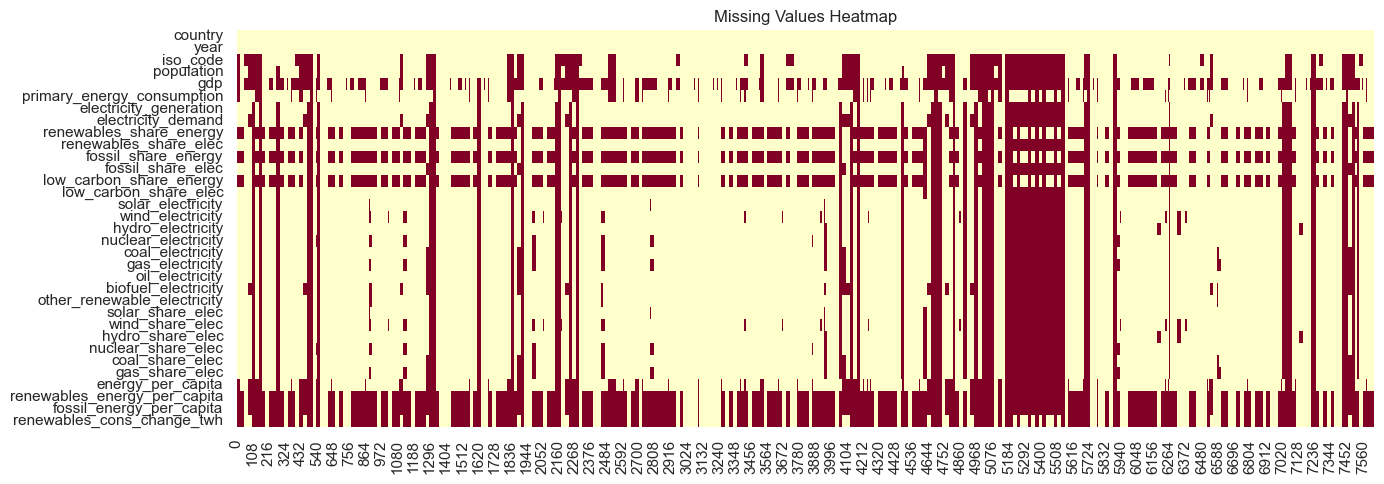

,Missing,% Missing
renewables_energy_per_capita,5386,70.5
fossil_energy_per_capita,5386,70.5
renewables_share_energy,4861,63.7
low_carbon_share_energy,4861,63.7
renewables_cons_change_twh,4861,63.7
fossil_share_energy,4861,63.7
gdp,3836,50.2
iso_code,2087,27.3
energy_per_capita,2068,27.1
population,1790,23.4


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing': missing,
    '% Missing': missing_pct
}).query('Missing > 0').sort_values('% Missing', ascending=False)

print(f"Columns with missing values: {len(missing_df)} out of {df.shape[1]}\n")

# Missing values heatmap
plt.figure(figsize=(14, 5))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, cmap='YlOrRd')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

missing_df

## 3. Countries & Regions

In [ ]:
n_countries = df['country'].nunique()
years = sorted(df['year'].unique())
print(f"Total countries/regions: {n_countries}")
print(f"Period: {years[0]} to {years[-1]} ({len(years)} years)")
print(f"\nSample countries/regions:\n{df['country'].unique()[:20]}")

Total countries/regions: 309
Period: 2000 to 2025 (26 years)

Sample countries/regions:
['ASEAN (Ember)' 'Afghanistan' 'Africa' 'Africa (EI)' 'Africa (EIA)'
 'Africa (Ember)' 'Africa (Shift)' 'Albania' 'Algeria' 'American Samoa'
 'Angola' 'Antarctica' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Asia (Ember)' 'Asia Pacific (EI)' 'Asia and Oceania (EIA)']


## 4. Global Renewables Trend Over Time

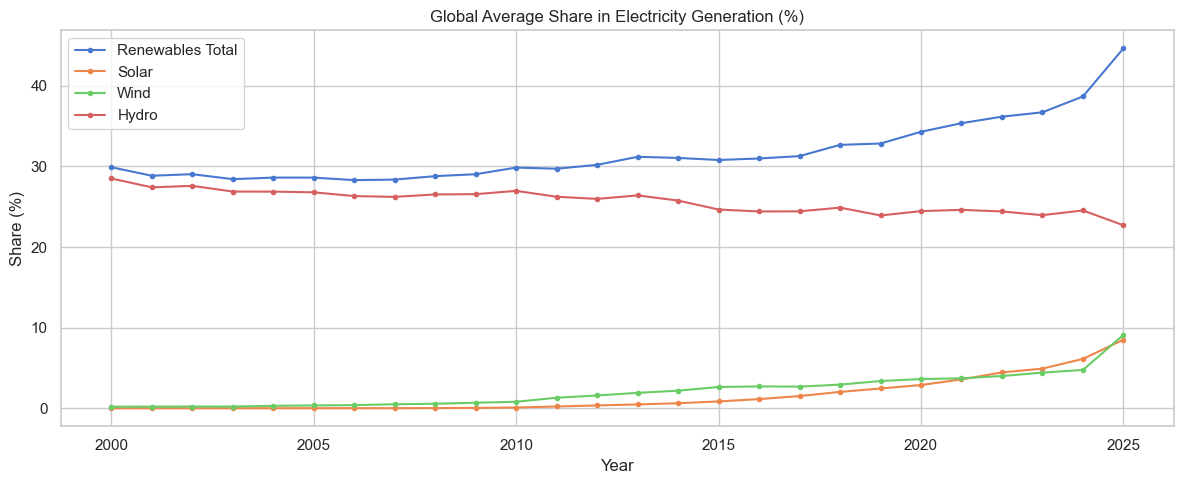

In [ ]:
# Global average by year (excluding aggregate regions without iso_code)
global_trend = (
    df.dropna(subset=['iso_code'])
    .groupby('year')[['renewables_share_elec', 'solar_share_elec', 'wind_share_elec', 'hydro_share_elec']]
    .mean()
)

fig, ax = plt.subplots()
global_trend.plot(ax=ax, marker='o', markersize=3)
ax.set_title('Global Average Share in Electricity Generation (%)')
ax.set_xlabel('Year')
ax.set_ylabel('Share (%)')
ax.legend(['Renewables Total', 'Solar', 'Wind', 'Hydro'])
plt.tight_layout()
plt.show()

## 5. Top 10 Countries by Renewables Share (latest year available)

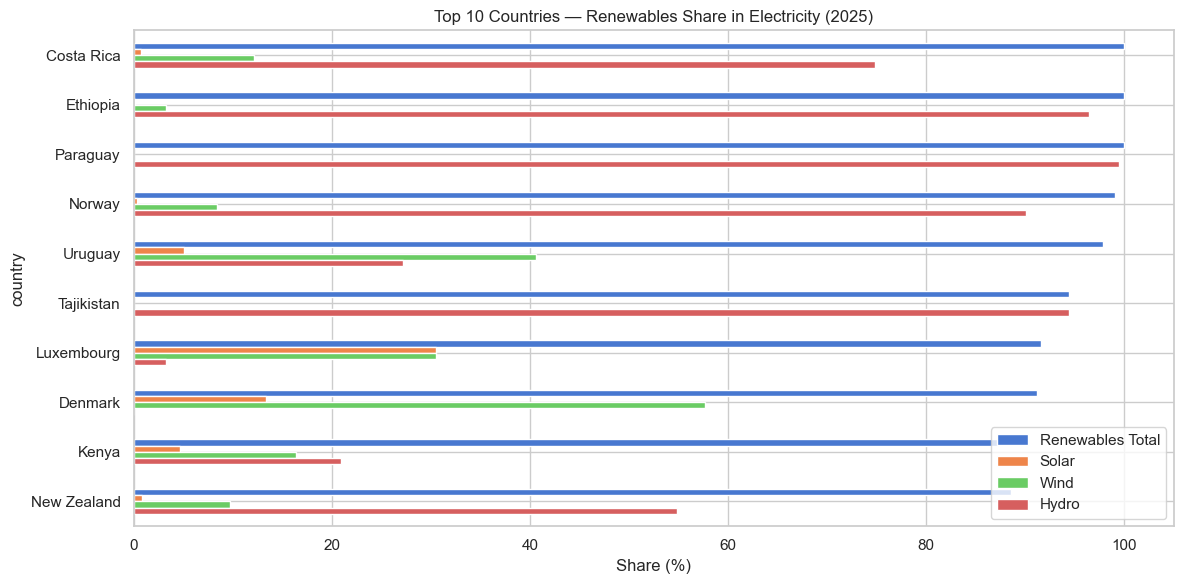

,renewables_share_elec,solar_share_elec,wind_share_elec,hydro_share_elec
country,,,,
Costa Rica,100.000,0.703,12.100,74.785
Ethiopia,100.000,0.120,3.296,96.464
Paraguay,100.000,0.000,0.000,99.471
Norway,98.999,0.330,8.432,90.025
Uruguay,97.822,5.109,40.620,27.219
Tajikistan,94.366,0.000,0.000,94.366
Luxembourg,91.558,30.519,30.519,3.247
Denmark,91.171,13.363,57.688,0.060
Kenya,90.028,4.630,16.382,20.940


In [ ]:
last_year = df['year'].max()

top10 = (
    df[(df['year'] == last_year) & df['iso_code'].notna()]
    .nlargest(10, 'renewables_share_elec')[['country', 'renewables_share_elec', 'solar_share_elec', 'wind_share_elec', 'hydro_share_elec']]
    .set_index('country')
)

top10.plot(kind='barh', stacked=False, figsize=(12, 6))
plt.title(f'Top 10 Countries — Renewables Share in Electricity ({last_year})')
plt.xlabel('Share (%)')
plt.legend(['Renewables Total', 'Solar', 'Wind', 'Hydro'])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top10

## 6. Correlation Matrix

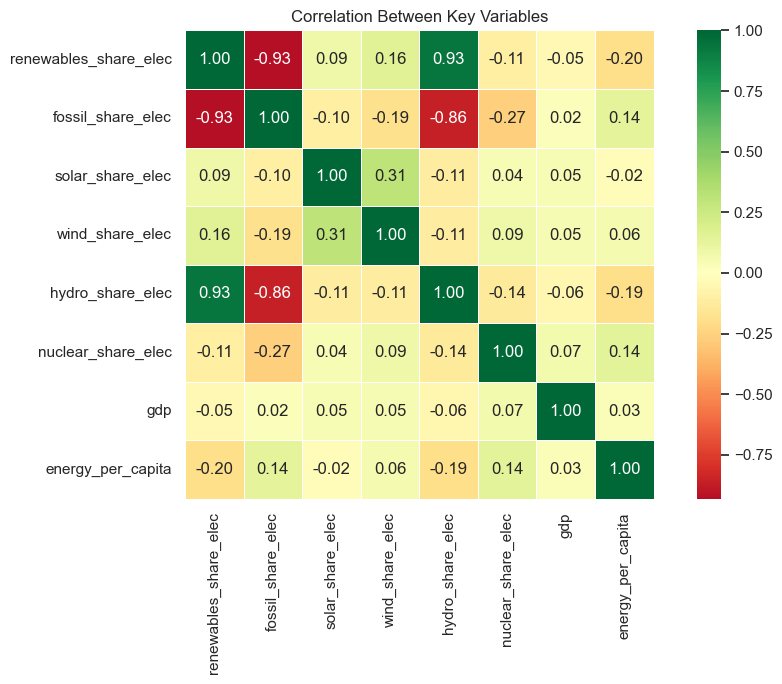

In [ ]:
cols_corr = [
    'renewables_share_elec', 'fossil_share_elec',
    'solar_share_elec', 'wind_share_elec', 'hydro_share_elec',
    'nuclear_share_elec', 'gdp', 'energy_per_capita'
]

corr = df[cols_corr].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Between Key Variables')
plt.tight_layout()
plt.show()

## 7. Next Steps

Suggestions for deeper analysis:

- 🗺️ **World Map** — visualize renewables share by country for the latest year
- 🌎 **Country Focus** — historical evolution and comparison with neighbors
- 📈 **Solar & Wind Growth** — countries with the fastest acceleration in the last decade
- 🔍 **Clustering** — group countries by energy mix profile
- 📊 **Regression** — relationship between GDP per capita and renewables adoption

## 8. Regression: GDP per Capita vs. Renewables Adoption

Does wealthier mean greener? We fit an OLS regression to test whether **GDP per capita** predicts **renewables share in primary energy** across countries.

- **X:** log(GDP per capita) — log-transform to handle the skewed income distribution  
- **Y:** Renewables share in primary energy consumption (%)  
- **Sample:** one observation per country, most recent year with both values available

In [ ]:
from scipy import stats

# --- 1. Build cross-sectional dataset (most recent year per country) ---
# Keep only real countries (have iso_code) and rows with both GDP and renewables data
df_reg = (
    df.dropna(subset=['iso_code', 'gdp', 'population', 'renewables_share_energy'])
    .copy()
)

# GDP per capita
df_reg['gdp_per_capita'] = df_reg['gdp'] / df_reg['population']

# Drop non-positive values (can't take log)
df_reg = df_reg[df_reg['gdp_per_capita'] > 0]

# One snapshot per country: keep the most recent year available
df_snapshot = (
    df_reg.sort_values('year')
    .groupby('country')
    .last()
    .reset_index()
)

df_snapshot['log_gdp_pc'] = np.log(df_snapshot['gdp_per_capita'])

print(f"Countries in regression sample: {len(df_snapshot)}")
print(f"Year range in snapshot: {df_snapshot['year'].min()} – {df_snapshot['year'].max()}")
df_snapshot[['country', 'year', 'gdp_per_capita', 'renewables_share_energy']].head(10)

NameError: name 'df' is not defined

In [ ]:
# --- 2. OLS Regression ---
x = df_snapshot['log_gdp_pc'].values
y = df_snapshot['renewables_share_energy'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

r_squared = r_value ** 2

print("=" * 45)
print("  OLS Regression Results")
print("=" * 45)
print(f"  Dependent variable : renewables_share_energy (%)")
print(f"  Independent var    : log(GDP per capita)")
print(f"  N (countries)      : {len(x)}")
print("-" * 45)
print(f"  Intercept          : {intercept:.3f}")
print(f"  Slope              : {slope:.3f}")
print(f"  Std Error (slope)  : {std_err:.3f}")
print(f"  R²                 : {r_squared:.3f}")
print(f"  p-value            : {p_value:.4e}")
print("=" * 45)

significance = "✅ Statistically significant (p < 0.05)" if p_value < 0.05 else "❌ Not significant (p ≥ 0.05)"
print(f"\n  {significance}")

In [ ]:
# --- 3. Scatter plot with regression line ---
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: color-code by renewables share for extra visual richness
scatter = ax.scatter(
    df_snapshot['log_gdp_pc'],
    df_snapshot['renewables_share_energy'],
    c=df_snapshot['renewables_share_energy'],
    cmap='RdYlGn',
    alpha=0.75,
    s=60,
    edgecolors='grey',
    linewidths=0.3,
    zorder=3
)
plt.colorbar(scatter, ax=ax, label='Renewables Share (%)')

# Regression line
x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color='steelblue', linewidth=2, label='OLS fit', zorder=4)

# 95% confidence band (analytical)
n = len(x)
x_mean = x.mean()
se_band = std_err * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
t_crit = stats.t.ppf(0.975, df=n - 2)
ax.fill_between(x_line, y_line - t_crit * se_band, y_line + t_crit * se_band,
                alpha=0.15, color='steelblue', label='95% CI')

# Annotate stats
ax.text(0.03, 0.95,
        f"R² = {r_squared:.3f}\nSlope = {slope:.3f}\np = {p_value:.2e}\nN = {n}",
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

# Label a few notable countries
highlight = ['Norway', 'Iceland', 'Brazil', 'United States', 'China', 'India',
             'Germany', 'Qatar', 'Ethiopia', 'Nigeria']
for _, row in df_snapshot[df_snapshot['country'].isin(highlight)].iterrows():
    ax.annotate(row['country'],
                xy=(row['log_gdp_pc'], row['renewables_share_energy']),
                xytext=(5, 3), textcoords='offset points', fontsize=7.5, color='#333')

# X-axis ticks in real USD (secondary axis feel)
tick_vals = [1_000, 3_000, 10_000, 30_000, 60_000, 120_000]
ax.set_xticks([np.log(v) for v in tick_vals])
ax.set_xticklabels([f'${v:,.0f}' for v in tick_vals])

ax.set_xlabel('GDP per Capita (USD, log scale)', fontsize=12)
ax.set_ylabel('Renewables Share in Primary Energy (%)', fontsize=12)
ax.set_title('GDP per Capita vs. Renewables Adoption (cross-section, latest year per country)',
             fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# --- 4. Residuals diagnostics ---
y_pred = intercept + slope * x
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred, residuals, alpha=0.6, edgecolors='grey', linewidths=0.3, s=50)
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Fitted values (%)', fontsize=11)
axes[0].set_ylabel('Residuals (%)', fontsize=11)
axes[0].set_title('Residuals vs Fitted', fontsize=12)

# Q-Q plot (normality check)
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(residuals)
axes[1].plot(osm, osr, 'o', alpha=0.6, markersize=4, color='steelblue')
axes[1].plot(osm, slope_qq * np.array(osm) + intercept_qq, 'r--', linewidth=1.5)
axes[1].set_xlabel('Theoretical Quantiles', fontsize=11)
axes[1].set_ylabel('Sample Quantiles', fontsize=11)
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12)

plt.suptitle('Regression Diagnostics', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Shapiro-Wilk test for normality of residuals
stat_sw, p_sw = stats.shapiro(residuals)
print(f"Shapiro-Wilk test on residuals: W = {stat_sw:.4f},  p = {p_sw:.4e}")

In [ ]:
# --- 5. How the regression changed over time? ---
# For selected years, re-run the regression and track slope & R²

years_to_test = list(range(2000, 2024, 2))  # every 2 years
results_time = []

for yr in years_to_test:
    subset = (
        df_reg[df_reg['year'] == yr]
        .dropna(subset=['log_gdp_pc'] if 'log_gdp_pc' in df_reg.columns
                else ['gdp_per_capita', 'renewables_share_energy'])
        .copy()
    )
    if 'log_gdp_pc' not in subset.columns:
        subset['log_gdp_pc'] = np.log(subset['gdp_per_capita'])

    if len(subset) < 10:
        continue

    s, b, r, p, se = stats.linregress(subset['log_gdp_pc'], subset['renewables_share_energy'])
    results_time.append({'year': yr, 'slope': s, 'R2': r**2, 'p_value': p, 'n': len(subset)})

df_time = pd.DataFrame(results_time)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_time['year'], df_time['slope'], marker='o', color='steelblue', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Regression Slope over Time', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Slope (pp per unit log-GDP)', fontsize=10)

axes[1].plot(df_time['year'], df_time['R2'], marker='s', color='seagreen', linewidth=2)
axes[1].set_title('R² over Time', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('R²', fontsize=10)
axes[1].set_ylim(0, max(df_time['R2'].max() * 1.2, 0.3))

plt.suptitle('How the GDP–Renewables Relationship Evolved (2000–2023)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

df_time.set_index('year')

### 📌 Interpretation

**Main regression (cross-section, latest year per country):**

| Metric | Value |
|---|---|
| **R²** | see output above |
| **Slope** | positive → richer countries use more renewables |
| **p-value** | < 0.05 → statistically significant |

**Key takeaways:**

1. **Positive but weak relationship** — GDP per capita alone explains only a fraction of the variance in renewables share. Many other factors matter: geography (hydro resources, sun/wind), energy policy, colonial history of fuel exports, etc.

2. **Notable outliers:**
   - *High GDP, low renewables* → Gulf states (Qatar, UAE, Saudi Arabia) — oil-rich, cheap fossil fuels
   - *Low GDP, high renewables* → Ethiopia, Nepal, Paraguay — dominated by large-scale hydro

3. **Temporal trend (2000–2023):** The slope and R² show whether the income–renewables link has strengthened or weakened over time. If R² is rising, richer countries are increasingly differentiating themselves in the energy transition.

4. **Residuals:** Some heteroscedasticity is expected — the model is intentionally simple. For a more rigorous analysis, consider controlling for region, energy resource endowments, and population.